# K-Means Feature Space Analysis: SST vs Chlorophyll-a vs SSL

This notebook builds a standardized (z-scored) feature space from SST, Chlorophyll-a, SSL, and month, runs K-means clustering, and applies the trained model to a June mean-state cluster map.

In [123]:
# Import required libraries
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm

## Load the Pickle Dataset

In [124]:
# Load the pickle file
with open(r'E:\satdata\Custom\yucatan_sst_chlor_cdomslope_ssl_bathy_2010-2019_v3.pkl', 'rb') as f:
    data = pickle.load(f)

df = data['data']
metadata = data['metadata']

print(f"Dataset loaded successfully!")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Total records: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nData availability:")
print(f"  SST: {df['sst'].notna().sum()} days")
print(f"  Chlorophyll: {df['chlorophyll'].notna().sum()} days")
print(f"  SSL: {df['ssl'].notna().sum()} days")

Dataset loaded successfully!
Date range: 2010-01-01 00:00:00 to 2020-01-01 00:00:00
Total records: 3662
Columns: ['sst', 'sst_n_points', 'chlorophyll', 'chlor_n_points', 'cdom_412', 'cdom', 'cdom_412_n_points', 'cdom_slope_275_295', 'cdom_slope_275_295_n_points', 'cdom_slope_300_600', 'cdom_slope_300_600_n_points', 'ssl', 'ssl_n_points']

Data availability:
  SST: 3662 days
  Chlorophyll: 3651 days
  SSL: 3652 days


## Extract and Flatten Data for Clustering

In [ ]:
# Extract all data points from the gridded dataset
sst_values = []
chlor_values = []
ssl_values = []
month_values = []
month_sin_values = []
month_cos_values = []

for date_idx, row in df.iterrows():
    month = date_idx.month
    year = date_idx.year
    days_in_year = 366 if (year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)) else 365
    year_progress = (date_idx.dayofyear - 1) / float(days_in_year)
    season_angle = 2 * np.pi * year_progress
    season_sin = np.sin(season_angle)
    season_cos = np.cos(season_angle)

    sst_grid = row['sst']
    chlor_grid = row['chlorophyll']
    ssl_grid = row['ssl']

    if sst_grid is None or chlor_grid is None or ssl_grid is None:
        continue
    if isinstance(sst_grid, float) and np.isnan(sst_grid):
        continue
    if isinstance(chlor_grid, float) and np.isnan(chlor_grid):
        continue
    if isinstance(ssl_grid, float) and np.isnan(ssl_grid):
        continue

    sst_array = np.array(sst_grid)
    chlor_array = np.array(chlor_grid)
    ssl_array = np.array(ssl_grid)

    ssl_nan_mask = np.isnan(ssl_array)
    if not ssl_nan_mask.all():
        ssl_filled = ssl_array.copy()
        ssl_filled[ssl_nan_mask] = np.nanmean(ssl_array)
        ssl_blurred = gaussian_filter(ssl_filled, sigma=2.0)
        ssl_blurred[ssl_nan_mask] = np.nan
        ssl_array = ssl_blurred

    sst_flat = sst_array.flatten()
    chlor_flat = chlor_array.flatten()
    ssl_flat = ssl_array.flatten()

    valid_mask = ~np.isnan(sst_flat) & ~np.isnan(chlor_flat) & ~np.isnan(ssl_flat) & (chlor_flat > 0)

    sst_values.extend(sst_flat[valid_mask])
    chlor_values.extend(chlor_flat[valid_mask])
    ssl_values.extend(ssl_flat[valid_mask])
    month_values.extend([month] * np.sum(valid_mask))
    month_sin_values.extend([season_sin] * np.sum(valid_mask))
    month_cos_values.extend([season_cos] * np.sum(valid_mask))

sst_values = np.array(sst_values)
chlor_values = np.array(chlor_values)
ssl_values = np.array(ssl_values)
month_values = np.array(month_values)
month_sin_values = np.array(month_sin_values)
month_cos_values = np.array(month_cos_values)

print(f"Total valid data points before subsampling: {len(sst_values):,}")

max_points = 500000
if len(sst_values) > max_points:
    np.random.seed(42)
    random_indices = np.random.choice(len(sst_values), size=max_points, replace=False)
    sst_values = sst_values[random_indices]
    chlor_values = chlor_values[random_indices]
    ssl_values = ssl_values[random_indices]
    month_values = month_values[random_indices]
    month_sin_values = month_sin_values[random_indices]
    month_cos_values = month_cos_values[random_indices]
    print(f"Subsampled to {max_points:,} points")
else:
    print(f"Using all {len(sst_values):,} points (less than {max_points:,})")

print(f"Months represented: {sorted(np.unique(month_values))}")
print(f"SST range: {np.min(sst_values):.2f} to {np.max(sst_values):.2f} °C")
print(f"Chlorophyll range: {np.min(chlor_values):.4f} to {np.max(chlor_values):.4f} mg/m³")
print(f"SSL range: {np.min(ssl_values):.4f} to {np.max(ssl_values):.4f} m")
print(f"Season sin range: {np.min(month_sin_values):.3f} to {np.max(month_sin_values):.3f}")
print(f"Season cos range: {np.min(month_cos_values):.3f} to {np.max(month_cos_values):.3f}")

Total valid data points before subsampling: 60,419,911
Subsampled to 5,000 points
Months represented: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
SST range: 21.10 to 31.10 °C
Chlorophyll range: 0.0318 to 60.0630 mg/m³
SSL range: -0.0224 to 1.0623 m
Season sin range: -1.000 to 1.000
Season cos range: -1.000 to 1.000


In [126]:
# Prepare feature matrix: [log10(Chlor), SST, SSL, season_sin, season_cos]
chlor_log = np.log10(chlor_values)

features = np.column_stack([
    chlor_log,
    sst_values,
    ssl_values,
    month_sin_values,
    month_cos_values
])

print(f"Feature matrix shape: {features.shape}")
print("Features: [log10(Chlor), SST, SSL, season_sin, season_cos]")

# Z-score standardization before K-means
scaler = StandardScaler()
features_z = scaler.fit_transform(features)

print("\nZ-score scaling applied before K-means (mean≈0, std≈1)")
print(f"Scaled means: {np.round(features_z.mean(axis=0), 3)}")
print(f"Scaled stds : {np.round(features_z.std(axis=0), 3)}")

# Apply K-means on z-scored data
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(features_z)

print(f"\nK-means clustering with {n_clusters} clusters:")
for i in range(n_clusters):
    count = np.sum(cluster_labels == i)
    pct = 100 * count / len(cluster_labels)
    print(f"  Cluster {i}: {count:,} points ({pct:.1f}%)")

# Cluster centers mapped back to original feature scale
cluster_centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
print("\nCluster centers (original scale):")
feature_names = ['log10(Chlor)', 'SST', 'SSL', 'season_sin', 'season_cos']
for i in range(n_clusters):
    print(f"\n  Cluster {i}:")
    for j, name in enumerate(feature_names):
        print(f"    {name}: {cluster_centers_original[i, j]:.3f}")

def date_to_season_sin_cos(ts):
    year = ts.year
    days_in_year = 366 if (year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)) else 365
    year_progress = (ts.dayofyear - 1) / float(days_in_year)
    season_angle = 2 * np.pi * year_progress
    return np.sin(season_angle), np.cos(season_angle)

def month_midpoint_sin_cos(month_num):
    year_progress = (float(month_num) - 0.5) / 12.0
    season_angle = 2 * np.pi * year_progress
    return np.sin(season_angle), np.cos(season_angle)

# Compute PCA from z-scored feature matrix for visualization
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_z)
print(
    f"\nPCA computed — variance explained: "
    f"PC1={100*pca.explained_variance_ratio_[0]:.1f}%, "
    f"PC2={100*pca.explained_variance_ratio_[1]:.1f}% "
    f"(total={100*pca.explained_variance_ratio_.sum():.1f}%)"
 )

Feature matrix shape: (5000, 5)
Features: [log10(Chlor), SST, SSL, season_sin, season_cos]

Z-score scaling applied before K-means (mean≈0, std≈1)
Scaled means: [-0. -0.  0.  0. -0.]
Scaled stds : [1. 1. 1. 1. 1.]

K-means clustering with 4 clusters:
  Cluster 0: 1,149 points (23.0%)
  Cluster 1: 824 points (16.5%)
  Cluster 2: 1,503 points (30.1%)
  Cluster 3: 1,524 points (30.5%)

Cluster centers (original scale):

  Cluster 0:
    log10(Chlor): -0.253
    SST: 26.517
    SSL: 0.376
    season_sin: -0.513
    season_cos: 0.715

  Cluster 1:
    log10(Chlor): -1.094
    SST: 28.332
    SSL: 0.654
    season_sin: -0.117
    season_cos: 0.170

  Cluster 2:
    log10(Chlor): -0.508
    SST: 25.015
    SSL: 0.262
    season_sin: 0.748
    season_cos: 0.323

  Cluster 3:
    log10(Chlor): -0.674
    SST: 28.728
    SSL: 0.291
    season_sin: -0.339
    season_cos: -0.660

PCA computed — variance explained: PC1=42.6%, PC2=24.6% (total=67.2%)


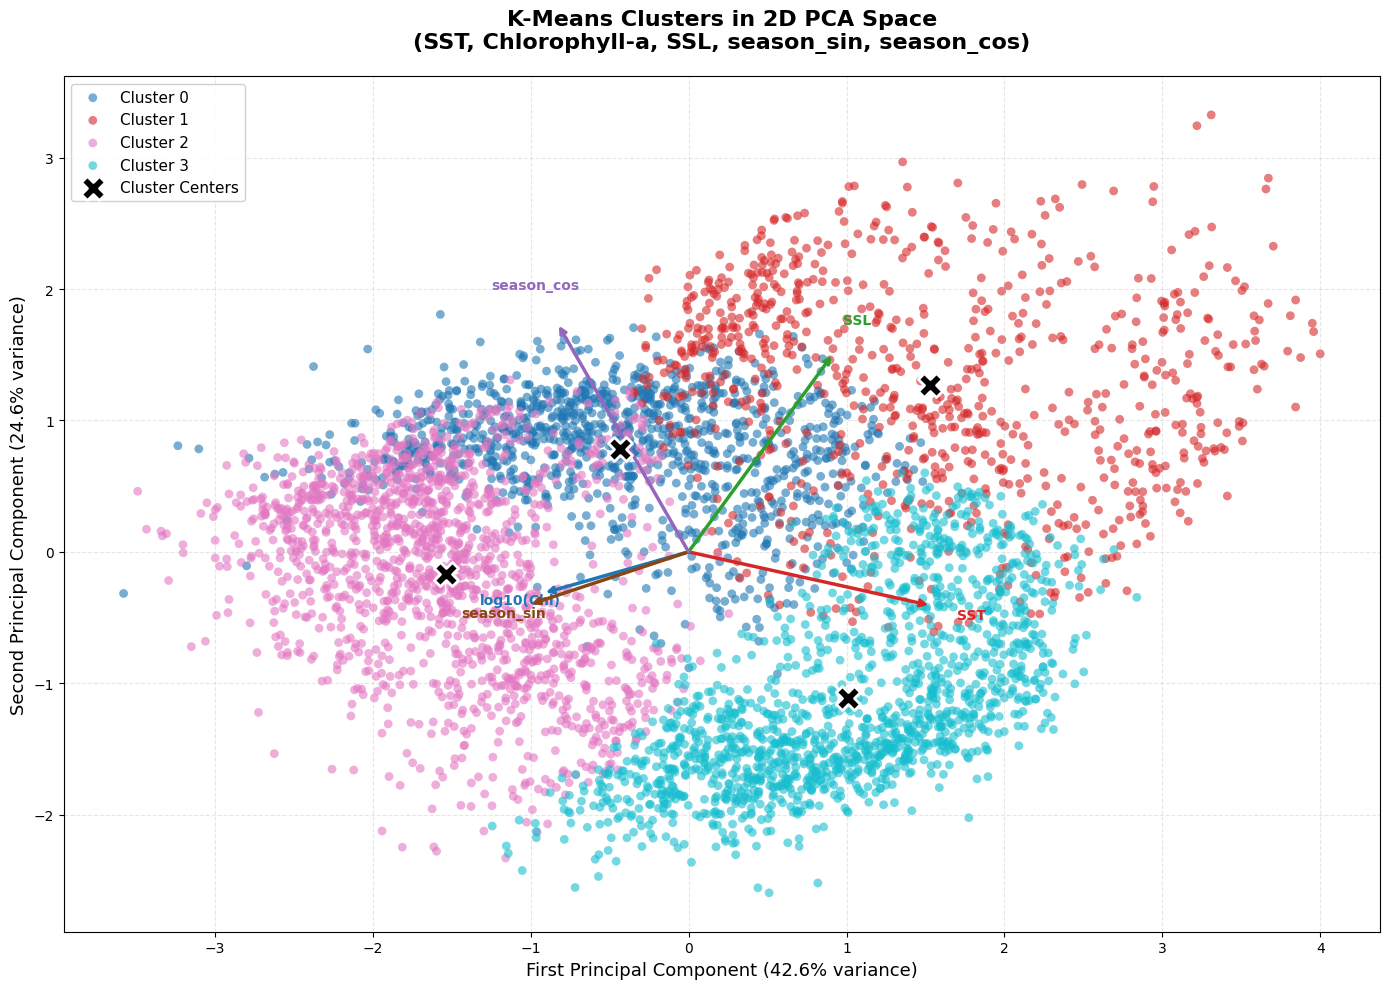


PCA visualization complete!
Total variance explained by 2 components: 67.2%


In [127]:
# Create 2D PCA visualization of clusters
fig, ax = plt.subplots(figsize=(14, 10))

# Define colors for clusters
cmap = plt.get_cmap('tab10', n_clusters)
colors = [cmap(i) for i in range(n_clusters)]
cluster_names = [f'Cluster {i}' for i in range(n_clusters)]

# Plot each cluster
for i in range(n_clusters):
    mask = cluster_labels == i
    ax.scatter(
        features_pca[mask, 0],
        features_pca[mask, 1],
        c=[colors[i]],
        label=cluster_names[i],
        s=40,
        alpha=0.6,
        edgecolors='none'
    )

# Plot cluster centers in PCA space
centers_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    c='black',
    marker='X',
    s=300,
    edgecolors='white',
    linewidths=2,
    label='Cluster Centers',
    zorder=5
)

# Labels and title
ax.set_xlabel(f'First Principal Component ({100*pca.explained_variance_ratio_[0]:.1f}% variance)', 
              fontsize=13)
ax.set_ylabel(f'Second Principal Component ({100*pca.explained_variance_ratio_[1]:.1f}% variance)', 
              fontsize=13)
ax.set_title('K-Means Clusters in 2D PCA Space\n(SST, Chlorophyll-a, SSL, season_sin, season_cos)', 
             fontsize=16, fontweight='bold', pad=20)

# --- PCA loading rays (biplot arrows) ---
# Scale arrows to ~40% of the smaller axis range so they are clearly visible
x_range = features_pca[:, 0].max() - features_pca[:, 0].min()
y_range = features_pca[:, 1].max() - features_pca[:, 1].min()
arrow_scale = min(x_range, y_range) * 0.4

loading_feature_names = ['log10(Chl)', 'SST', 'SSL', 'season_sin', 'season_cos']
loading_colors = ['tab:blue', 'tab:red', 'tab:green', 'saddlebrown', 'tab:purple']

for j, (fname, fcolor) in enumerate(zip(loading_feature_names, loading_colors)):
    dx = pca.components_[0, j] * arrow_scale
    dy = pca.components_[1, j] * arrow_scale
    ax.annotate(
        '', xy=(dx, dy), xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color=fcolor, lw=2.5, shrinkA=0, shrinkB=0)
    )
    ax.text(dx * 1.18, dy * 1.18, fname, color=fcolor, fontsize=10,
            fontweight='bold', ha='center', va='center')

# Legend
ax.legend(loc='best', fontsize=11, framealpha=0.9)

# Grid
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

print(f"\nPCA visualization complete!")
print(f"Total variance explained by 2 components: {100*np.sum(pca.explained_variance_ratio_):.1f}%")


C:\Users\Makai\AppData\Local\Temp\ipykernel_35492\1169925499.py:42: RuntimeWarning: Mean of empty slice
  mean_sst = np.nanmean(np.stack(june_sst_grids, axis=0), axis=0)
C:\Users\Makai\AppData\Local\Temp\ipykernel_35492\1169925499.py:43: RuntimeWarning: Mean of empty slice
  mean_chlor = np.nanmean(np.stack(june_chlor_grids, axis=0), axis=0)


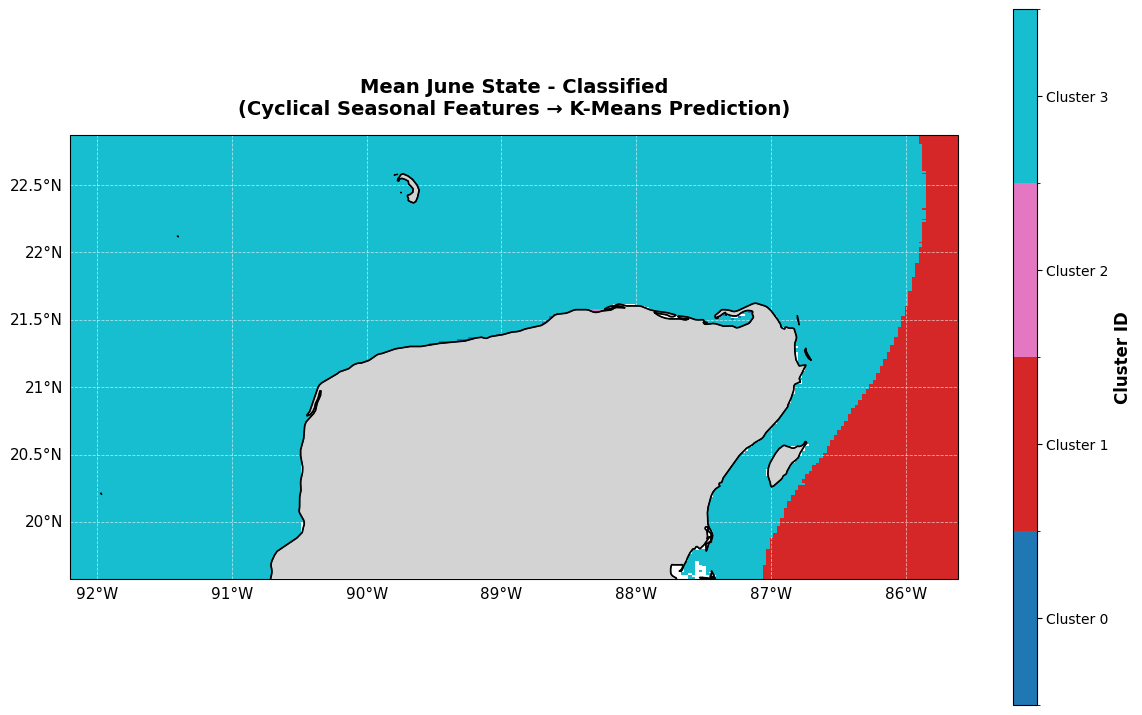

Mean June map generated!
Valid pixels classified: 45,035
June scenes averaged: 300


In [128]:
# Build June mean-state grids used for map classification
june_sst_grids = []
june_chlor_grids = []
june_ssl_grids = []

for date_idx, row in df.iterrows():
    if date_idx.month != 6:
        continue

    sst_grid = row['sst']
    chlor_grid = row['chlorophyll']
    ssl_grid = row['ssl']

    if sst_grid is None or chlor_grid is None or ssl_grid is None:
        continue
    if isinstance(sst_grid, float) and np.isnan(sst_grid):
        continue
    if isinstance(chlor_grid, float) and np.isnan(chlor_grid):
        continue
    if isinstance(ssl_grid, float) and np.isnan(ssl_grid):
        continue

    sst_arr = np.array(sst_grid, dtype=float)
    chlor_arr = np.array(chlor_grid, dtype=float)
    ssl_arr = np.array(ssl_grid, dtype=float)

    ssl_nan_mask = np.isnan(ssl_arr)
    if not ssl_nan_mask.all():
        ssl_filled = ssl_arr.copy()
        ssl_filled[ssl_nan_mask] = np.nanmean(ssl_arr)
        ssl_blurred = gaussian_filter(ssl_filled, sigma=2.0)
        ssl_blurred[ssl_nan_mask] = np.nan
        ssl_arr = ssl_blurred

    june_sst_grids.append(sst_arr)
    june_chlor_grids.append(chlor_arr)
    june_ssl_grids.append(ssl_arr)

if len(june_sst_grids) == 0:
    raise ValueError('No valid June records found for map generation.')

mean_sst = np.nanmean(np.stack(june_sst_grids, axis=0), axis=0)
mean_chlor = np.nanmean(np.stack(june_chlor_grids, axis=0), axis=0)
mean_ssl = np.nanmean(np.stack(june_ssl_grids, axis=0), axis=0)

lon_centers = np.array(metadata['lon_centers'])
lat_centers = np.array(metadata['lat_centers'])
if lon_centers.ndim == 1 and lat_centers.ndim == 1:
    lon_grid_2d, lat_grid_2d = np.meshgrid(lon_centers, lat_centers)
else:
    lon_grid_2d, lat_grid_2d = lon_centers, lat_centers

# Flatten the June mean grids for K-means prediction
mean_chlor_flat = mean_chlor.flatten()
mean_sst_flat = mean_sst.flatten()
mean_ssl_flat = mean_ssl.flatten()

valid_mask_mean = (
    ~np.isnan(mean_chlor_flat)
    & ~np.isnan(mean_sst_flat)
    & ~np.isnan(mean_ssl_flat)
    & (mean_chlor_flat > 0)
)

chlor_valid = mean_chlor_flat[valid_mask_mean]
sst_valid = mean_sst_flat[valid_mask_mean]
ssl_valid = mean_ssl_flat[valid_mask_mean]

# Match training feature format: [log10(Chlor), SST, SSL, season_sin, season_cos]
june_sin, june_cos = month_midpoint_sin_cos(6)
mean_features = np.column_stack([
    np.log10(chlor_valid),
    sst_valid,
    ssl_valid,
    np.full_like(sst_valid, june_sin),
    np.full_like(sst_valid, june_cos),
])

# Apply the same z-score transform and trained K-means model
mean_features_z = scaler.transform(mean_features)
mean_clusters = kmeans.predict(mean_features_z)

mean_cluster_grid = np.full(mean_chlor.shape, np.nan)
mean_cluster_grid.flat[valid_mask_mean] = mean_clusters

# Plot the smooth cluster map
fig = plt.figure(figsize=(12, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

lat_min, lon_min = 19.57871, -92.20216
lat_max, lon_max = 22.86906, -85.61256
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

cmap_base = plt.get_cmap('tab10', n_clusters)
colors = [cmap_base(i) for i in range(n_clusters)]
cmap = ListedColormap(colors)
bounds = np.arange(-0.5, n_clusters + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

mesh = ax.pcolormesh(
    lon_grid_2d,
    lat_grid_2d,
    mean_cluster_grid,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree(),
    shading='auto',
    zorder=1
)

ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.8, zorder=3)
ax.add_feature(cfeature.COASTLINE, linewidth=1.2, zorder=4)

gl = ax.gridlines(draw_labels=True, linewidth=0.6, color='white', alpha=0.6, linestyle='--', zorder=2)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 11}
gl.ylabel_style = {'size': 11}

cluster_names = [f'Cluster {i}' for i in range(n_clusters)]
cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', pad=0.05, shrink=0.8, aspect=30)
cbar.set_label('Cluster ID', fontsize=12, weight='bold')
cbar.set_ticks(np.arange(0, n_clusters, 1))
cbar.ax.set_yticklabels(cluster_names, fontsize=10)

plt.title(
    'Mean June State - Classified\n(Cyclical Seasonal Features → K-Means Prediction)',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.tight_layout()
plt.show()

print('Mean June map generated!')
print(f'Valid pixels classified: {np.sum(valid_mask_mean):,}')
print(f'June scenes averaged: {len(june_sst_grids)}')

## Monthly CDOM Comparison: Upwelling vs Non-Upwelling

This section uses all months (January–December), assigns each valid pixel to the trained K-means clusters, then merges clusters into:

- **Upwelling**: Cluster 1
- **Non-Upwelling**: Clusters 0 + 2 + 3

It generates three separate figures (one per CDOM variable):

1. `S275:295`
2. `S300:600`
3. `a(412)`

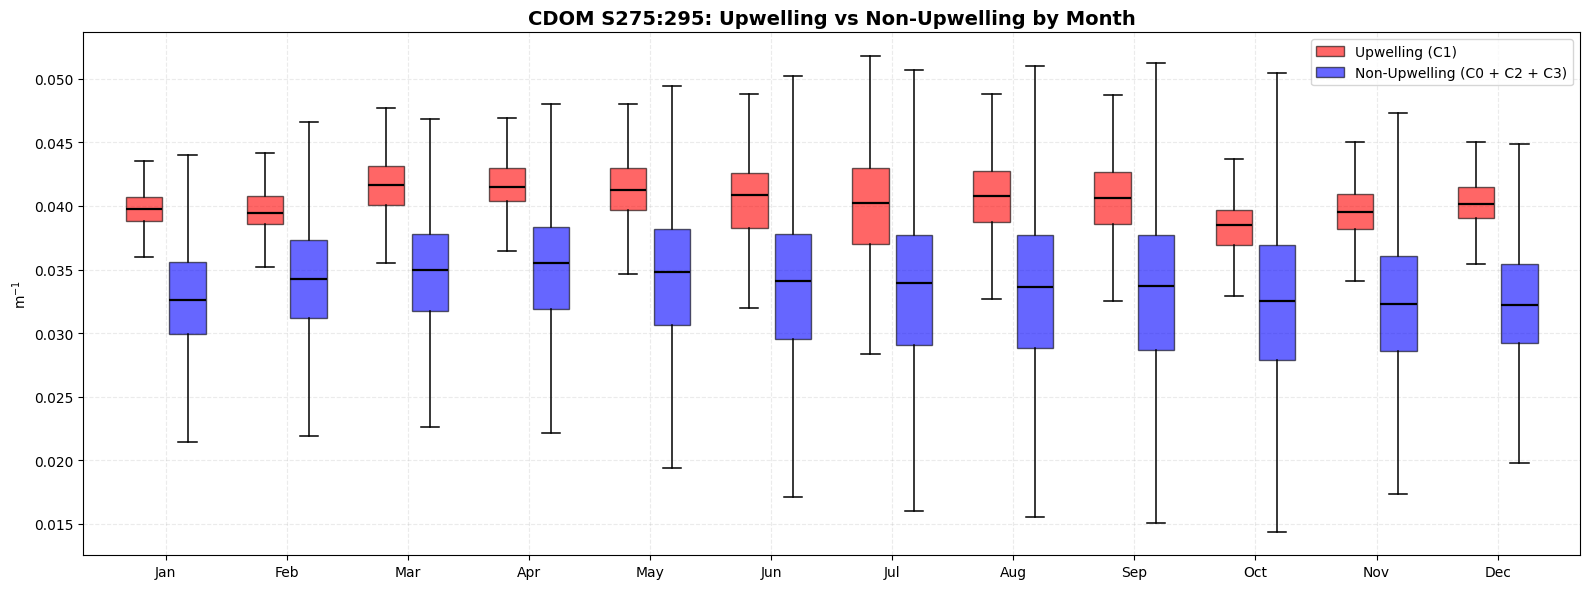

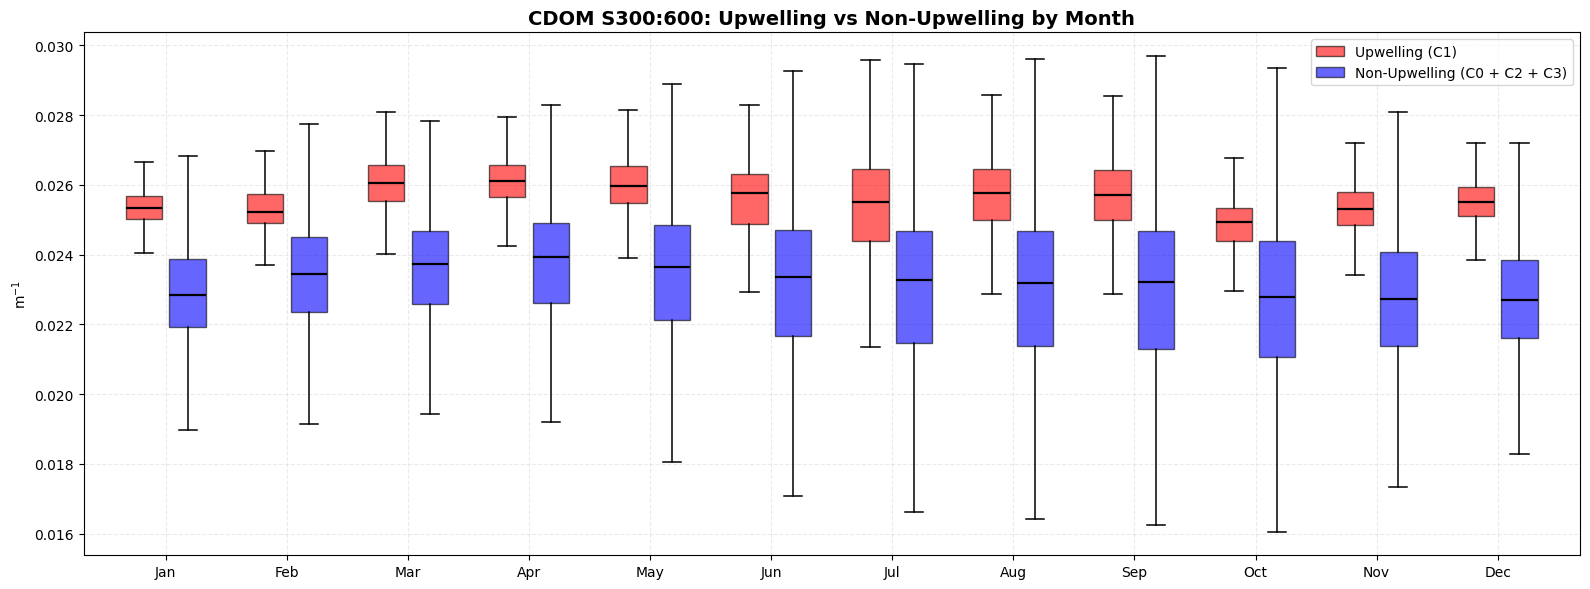

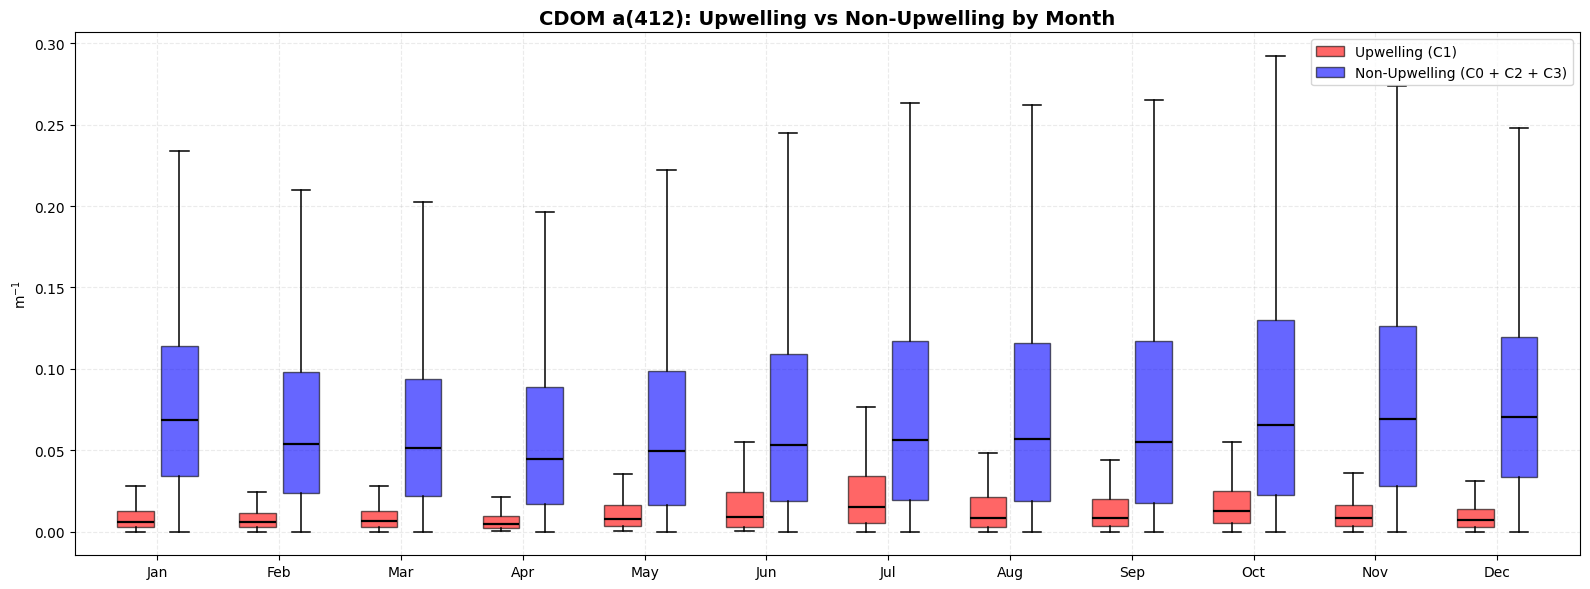

Generated 3 figures for monthly Upwelling vs Non-Upwelling CDOM comparisons.
  Jan: Upwelling=53,780, Non-Upwelling=3,698,220
  Feb: Upwelling=50,047, Non-Upwelling=4,335,885
  Mar: Upwelling=10,796, Non-Upwelling=4,057,205
  Apr: Upwelling=2,762, Non-Upwelling=2,498,317
  May: Upwelling=1,516, Non-Upwelling=2,378,200
  Jun: Upwelling=990, Non-Upwelling=1,760,394
  Jul: Upwelling=1,595, Non-Upwelling=2,008,173
  Aug: Upwelling=2,496, Non-Upwelling=2,002,020
  Sep: Upwelling=7,456, Non-Upwelling=1,932,995
  Oct: Upwelling=200,997, Non-Upwelling=2,523,403
  Nov: Upwelling=54,175, Non-Upwelling=3,538,501
  Dec: Upwelling=40,569, Non-Upwelling=4,121,713


In [129]:
# Extract all-month pixel values and assign clusters using trained model
all_month_labels = []
all_month_clusters = []
all_month_s275 = []
all_month_s300 = []
all_month_a412 = []

def _is_missing_grid_local(grid_obj):
    return grid_obj is None or (isinstance(grid_obj, float) and np.isnan(grid_obj))

for date_idx, row in df.iterrows():
    month = int(date_idx.month)
    season_sin, season_cos = date_to_season_sin_cos(date_idx)

    sst_grid = row.get('sst', np.nan)
    chlor_grid = row.get('chlorophyll', np.nan)
    ssl_grid = row.get('ssl', np.nan)
    s275_grid = row.get('cdom_slope_275_295', np.nan)
    s300_grid = row.get('cdom_slope_300_600', np.nan)
    a412_grid = row.get('cdom_412', row.get('cdom', np.nan))

    if any(_is_missing_grid_local(g) for g in [sst_grid, chlor_grid, ssl_grid, s275_grid, s300_grid, a412_grid]):
        continue

    sst_array = np.array(sst_grid, dtype=float)
    chlor_array = np.array(chlor_grid, dtype=float)
    ssl_array = np.array(ssl_grid, dtype=float)
    s275_array = np.array(s275_grid, dtype=float)
    s300_array = np.array(s300_grid, dtype=float)
    a412_array = np.array(a412_grid, dtype=float)

    ssl_nan_mask = np.isnan(ssl_array)
    if not ssl_nan_mask.all():
        ssl_filled = ssl_array.copy()
        ssl_filled[ssl_nan_mask] = np.nanmean(ssl_array)
        ssl_blurred = gaussian_filter(ssl_filled, sigma=2.0)
        ssl_blurred[ssl_nan_mask] = np.nan
        ssl_array = ssl_blurred

    sst_flat = sst_array.flatten()
    chlor_flat = chlor_array.flatten()
    ssl_flat = ssl_array.flatten()
    s275_flat = s275_array.flatten()
    s300_flat = s300_array.flatten()
    a412_flat = a412_array.flatten()

    valid_mask = (
        ~np.isnan(sst_flat)
        & ~np.isnan(chlor_flat)
        & ~np.isnan(ssl_flat)
        & ~np.isnan(s275_flat)
        & ~np.isnan(s300_flat)
        & ~np.isnan(a412_flat)
        & (chlor_flat > 0)
        & (a412_flat > 0)
    )

    if not np.any(valid_mask):
        continue

    features_month = np.column_stack([
        np.log10(chlor_flat[valid_mask]),
        sst_flat[valid_mask],
        ssl_flat[valid_mask],
        np.full(np.sum(valid_mask), season_sin),
        np.full(np.sum(valid_mask), season_cos),
    ])

    features_month_z = scaler.transform(features_month)
    clusters_month = kmeans.predict(features_month_z)

    all_month_labels.extend([month] * int(np.sum(valid_mask)))
    all_month_clusters.extend(clusters_month)
    all_month_s275.extend(s275_flat[valid_mask])
    all_month_s300.extend(s300_flat[valid_mask])
    all_month_a412.extend(a412_flat[valid_mask])

all_month_labels = np.array(all_month_labels, dtype=int)
all_month_clusters = np.array(all_month_clusters)
all_month_s275 = np.array(all_month_s275)
all_month_s300 = np.array(all_month_s300)
all_month_a412 = np.array(all_month_a412)

if all_month_labels.size == 0:
    raise ValueError('No valid all-month pixels found for CDOM comparison.')

upwelling_mask = all_month_clusters == 1
non_upwelling_mask = np.isin(all_month_clusters, [0, 2, 3])

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

def plot_monthly_upwelling_vs_nonupwelling(values, var_title, y_unit):
    fig, ax = plt.subplots(figsize=(16, 6))

    up_data = []
    non_data = []
    up_positions = []
    non_positions = []
    tick_positions = []

    for month in range(1, 13):
        month_mask = all_month_labels == month
        up_vals = values[month_mask & upwelling_mask]
        non_vals = values[month_mask & non_upwelling_mask]

        if up_vals.size == 0:
            up_vals = np.array([np.nan])
        if non_vals.size == 0:
            non_vals = np.array([np.nan])

        center = month
        up_positions.append(center - 0.18)
        non_positions.append(center + 0.18)
        tick_positions.append(center)

        up_data.append(up_vals)
        non_data.append(non_vals)

    bp_up = ax.boxplot(
        up_data,
        positions=up_positions,
        widths=0.30,
        patch_artist=True,
        showfliers=False,
        medianprops={'color': 'black', 'linewidth': 1.6},
        whiskerprops={'linewidth': 1.1},
        capprops={'linewidth': 1.1},
    )
    for patch in bp_up['boxes']:
        patch.set_facecolor('red')
        patch.set_alpha(0.60)
        patch.set_edgecolor('black')

    bp_non = ax.boxplot(
        non_data,
        positions=non_positions,
        widths=0.30,
        patch_artist=True,
        showfliers=False,
        medianprops={'color': 'black', 'linewidth': 1.6},
        whiskerprops={'linewidth': 1.1},
        capprops={'linewidth': 1.1},
    )
    for patch in bp_non['boxes']:
        patch.set_facecolor('blue')
        patch.set_alpha(0.60)
        patch.set_edgecolor('black')

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(month_names)
    ax.set_ylabel(y_unit)
    ax.set_title(f'{var_title}: Upwelling vs Non-Upwelling by Month',
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.25, linestyle='--')

    from matplotlib.patches import Patch
    legend_handles = [
        Patch(facecolor='red', edgecolor='black', alpha=0.60, label='Upwelling (C1)'),
        Patch(facecolor='blue', edgecolor='black', alpha=0.60, label='Non-Upwelling (C0 + C2 + C3)'),
    ]
    ax.legend(handles=legend_handles, loc='best')

    plt.tight_layout()
    plt.show()

plot_monthly_upwelling_vs_nonupwelling(all_month_s275, 'CDOM S275:295', 'm$^{-1}$')
plot_monthly_upwelling_vs_nonupwelling(all_month_s300, 'CDOM S300:600', 'm$^{-1}$')
plot_monthly_upwelling_vs_nonupwelling(all_month_a412, 'CDOM a(412)', 'm$^{-1}$')

print('Generated 3 figures for monthly Upwelling vs Non-Upwelling CDOM comparisons.')
for month in range(1, 13):
    month_mask = all_month_labels == month
    n_up = np.sum(month_mask & upwelling_mask)
    n_non = np.sum(month_mask & non_upwelling_mask)
    print(f'  {month_names[month-1]}: Upwelling={n_up:,}, Non-Upwelling={n_non:,}')

## Monthly Cluster Maps (All 12 Months)

This cell computes a monthly mean state for each month (Jan–Dec), applies the trained K-means model, and plots all 12 classified maps in a 3×4 panel.

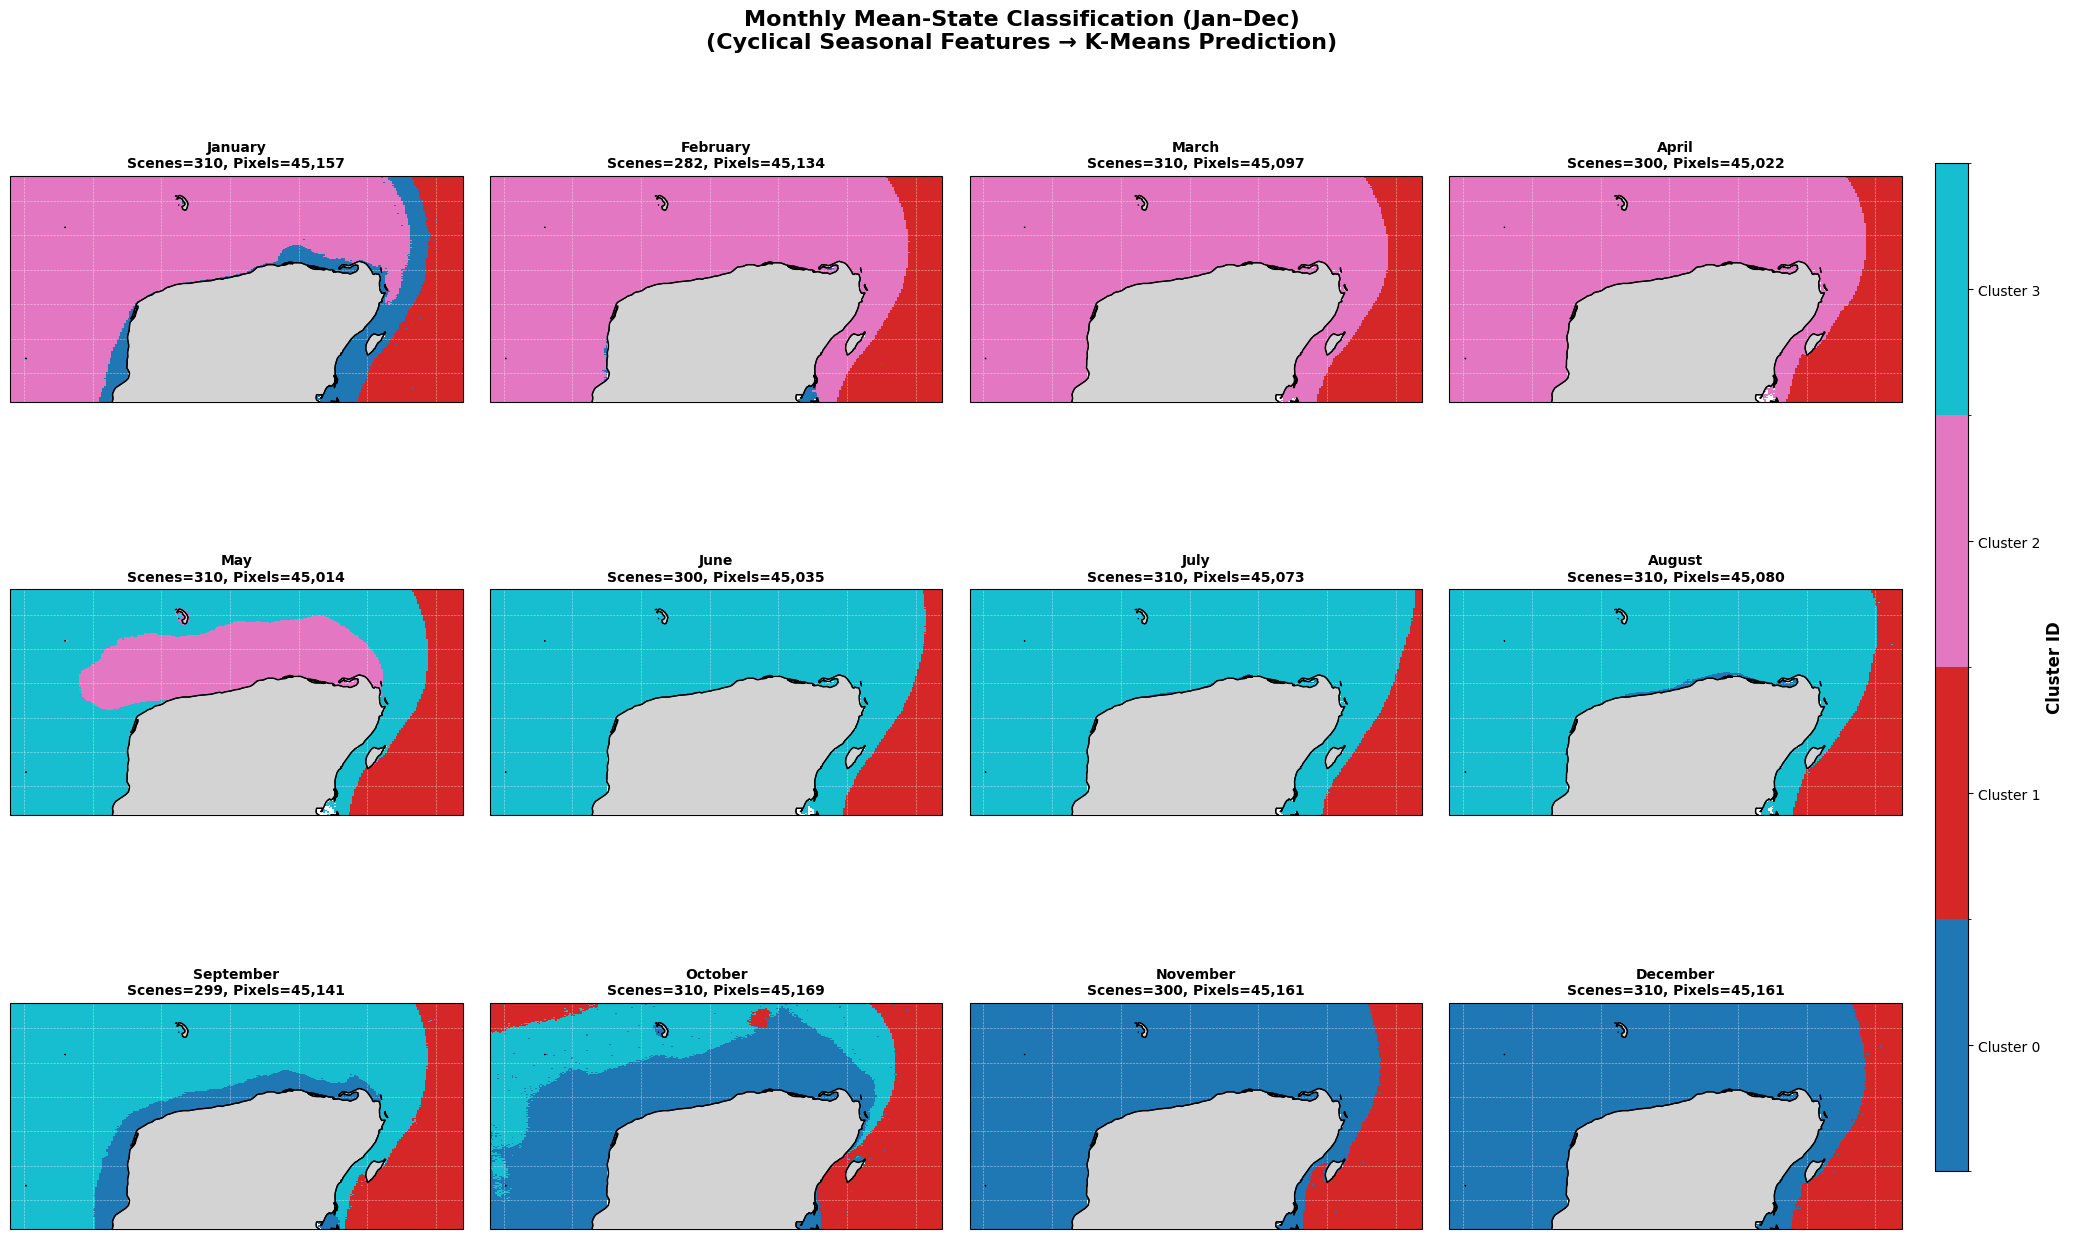

Generated 12 monthly classified maps.
  January: Scenes=310, Valid pixels=45,157
  February: Scenes=282, Valid pixels=45,134
  March: Scenes=310, Valid pixels=45,097
  April: Scenes=300, Valid pixels=45,022
  May: Scenes=310, Valid pixels=45,014
  June: Scenes=300, Valid pixels=45,035
  July: Scenes=310, Valid pixels=45,073
  August: Scenes=310, Valid pixels=45,080
  September: Scenes=299, Valid pixels=45,141
  October: Scenes=310, Valid pixels=45,169
  November: Scenes=300, Valid pixels=45,161
  December: Scenes=310, Valid pixels=45,161


In [130]:
# Plot monthly classified maps for all 12 months (3x4 panel)
import warnings

month_names_full = ['January', 'February', 'March', 'April', 'May', 'June',
                    'July', 'August', 'September', 'October', 'November', 'December']

# Build plotting domain from metadata
lon_centers = np.array(metadata['lon_centers'])
lat_centers = np.array(metadata['lat_centers'])
if lon_centers.ndim == 1 and lat_centers.ndim == 1:
    lon_grid_2d, lat_grid_2d = np.meshgrid(lon_centers, lat_centers)
else:
    lon_grid_2d, lat_grid_2d = lon_centers, lat_centers

lat_min, lon_min = 19.57871, -92.20216
lat_max, lon_max = 22.86906, -85.61256

cmap_base = plt.get_cmap('tab10', n_clusters)
cluster_colors = [cmap_base(i) for i in range(n_clusters)]
cluster_cmap = ListedColormap(cluster_colors)
bounds = np.arange(-0.5, n_clusters + 0.5, 1)
norm = BoundaryNorm(bounds, cluster_cmap.N)
cluster_names = [f'Cluster {i}' for i in range(n_clusters)]

fig, axes = plt.subplots(
    3,
    4,
    figsize=(22, 14),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

mesh_for_cbar = None
monthly_stats = []

for month_num, ax in enumerate(axes.ravel(), start=1):
    month_sst_grids = []
    month_chlor_grids = []
    month_ssl_grids = []

    for date_idx, row in df.iterrows():
        if int(date_idx.month) != month_num:
            continue

        sst_grid = row.get('sst', np.nan)
        chlor_grid = row.get('chlorophyll', np.nan)
        ssl_grid = row.get('ssl', np.nan)

        if sst_grid is None or chlor_grid is None or ssl_grid is None:
            continue
        if isinstance(sst_grid, float) and np.isnan(sst_grid):
            continue
        if isinstance(chlor_grid, float) and np.isnan(chlor_grid):
            continue
        if isinstance(ssl_grid, float) and np.isnan(ssl_grid):
            continue

        sst_arr = np.array(sst_grid, dtype=float)
        chlor_arr = np.array(chlor_grid, dtype=float)
        ssl_arr = np.array(ssl_grid, dtype=float)

        ssl_nan_mask = np.isnan(ssl_arr)
        if not ssl_nan_mask.all():
            ssl_filled = ssl_arr.copy()
            ssl_filled[ssl_nan_mask] = np.nanmean(ssl_arr)
            ssl_blurred = gaussian_filter(ssl_filled, sigma=2.0)
            ssl_blurred[ssl_nan_mask] = np.nan
            ssl_arr = ssl_blurred

        month_sst_grids.append(sst_arr)
        month_chlor_grids.append(chlor_arr)
        month_ssl_grids.append(ssl_arr)

    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    if len(month_sst_grids) == 0:
        ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.8, zorder=3)
        ax.add_feature(cfeature.COASTLINE, linewidth=1.0, zorder=4)
        ax.set_title(f"{month_names_full[month_num-1]}\nNo valid scenes", fontsize=11, fontweight='bold')
        monthly_stats.append((month_num, 0, 0))
        continue

    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category=RuntimeWarning)
        mean_sst = np.nanmean(np.stack(month_sst_grids, axis=0), axis=0)
        mean_chlor = np.nanmean(np.stack(month_chlor_grids, axis=0), axis=0)
        mean_ssl = np.nanmean(np.stack(month_ssl_grids, axis=0), axis=0)

    mean_chlor_flat = mean_chlor.flatten()
    mean_sst_flat = mean_sst.flatten()
    mean_ssl_flat = mean_ssl.flatten()

    valid_mask = (
        ~np.isnan(mean_chlor_flat)
        & ~np.isnan(mean_sst_flat)
        & ~np.isnan(mean_ssl_flat)
        & (mean_chlor_flat > 0)
    )

    cluster_grid = np.full(mean_chlor.shape, np.nan)

    if np.any(valid_mask):
        month_sin, month_cos = month_midpoint_sin_cos(month_num)
        month_features = np.column_stack([
            np.log10(mean_chlor_flat[valid_mask]),
            mean_sst_flat[valid_mask],
            mean_ssl_flat[valid_mask],
            np.full(np.sum(valid_mask), month_sin),
            np.full(np.sum(valid_mask), month_cos),
        ])

        month_features_z = scaler.transform(month_features)
        month_clusters = kmeans.predict(month_features_z)
        cluster_grid.flat[valid_mask] = month_clusters

    mesh = ax.pcolormesh(
        lon_grid_2d,
        lat_grid_2d,
        cluster_grid,
        cmap=cluster_cmap,
        norm=norm,
        transform=ccrs.PlateCarree(),
        shading='auto',
        zorder=1
    )
    if mesh_for_cbar is None:
        mesh_for_cbar = mesh

    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.8, zorder=3)
    ax.add_feature(cfeature.COASTLINE, linewidth=1.0, zorder=4)

    ax.gridlines(draw_labels=False, linewidth=0.45, color='white', alpha=0.55, linestyle='--', zorder=2)

    scene_count = len(month_sst_grids)
    valid_pixels = int(np.sum(valid_mask))
    ax.set_title(
        f"{month_names_full[month_num-1]}\nScenes={scene_count}, Pixels={valid_pixels:,}",
        fontsize=10,
        fontweight='bold'
    )

    monthly_stats.append((month_num, scene_count, valid_pixels))

# Reserve right margin for colorbar to avoid overlap with panels
fig.subplots_adjust(left=0.04, right=0.90, bottom=0.05, top=0.90, wspace=0.06, hspace=0.14)

if mesh_for_cbar is not None:
    cax = fig.add_axes([0.915, 0.14, 0.015, 0.72])
    cbar = fig.colorbar(mesh_for_cbar, cax=cax)
    cbar.set_label('Cluster ID', fontsize=12, weight='bold')
    cbar.set_ticks(np.arange(0, n_clusters, 1))
    cbar.ax.set_yticklabels(cluster_names, fontsize=10)

fig.suptitle('Monthly Mean-State Classification (Jan–Dec)\n(Cyclical Seasonal Features → K-Means Prediction)',
             fontsize=16, fontweight='bold', y=0.97)
plt.show()

print('Generated 12 monthly classified maps.')
for month_num, scene_count, valid_pixels in monthly_stats:
    print(f"  {month_names_full[month_num-1]}: Scenes={scene_count}, Valid pixels={valid_pixels:,}")